<a href="https://colab.research.google.com/github/SitiFadhilahRahmi/2311532003_Siti-Fadhilah-Rahmi_ImageProcessing/blob/main/Konvolusi_Tugas3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
from PIL import Image

# Ambil Gambar dari GitHub
url = "https://raw.githubusercontent.com/SitiFadhilahRahmi/Image-Processing-Semester-6/e12708cb7a9053dfdeffd35accf5002976a492ee/image.jpeg"
response = requests.get(url)
img_raw = Image.open(BytesIO(response.content)).convert('L')
img = np.array(img_raw)

In [ ]:
def konvolusi(img_gray):
    M, N = img_gray.shape

    # Definisikan Kernel Rataan 5x5
    kernel_size = 5
    kernel = np.ones((kernel_size, kernel_size)) / 25.0

    # Tambahkan Padding
    pad = 2
    img_padded = np.zeros((M + 2*pad, N + 2*pad))
    img_padded[pad:-pad, pad:-pad] = img_gray

    # Inisialisasi Matriks Hasil
    img_result = np.zeros((M, N))

    # Proses Konvolusi
    for i in range(M):
        for j in range(N):
            region = img_padded[i:i+kernel_size, j:j+kernel_size]

            img_result[i, j] = np.sum(region * kernel)

    return img_result

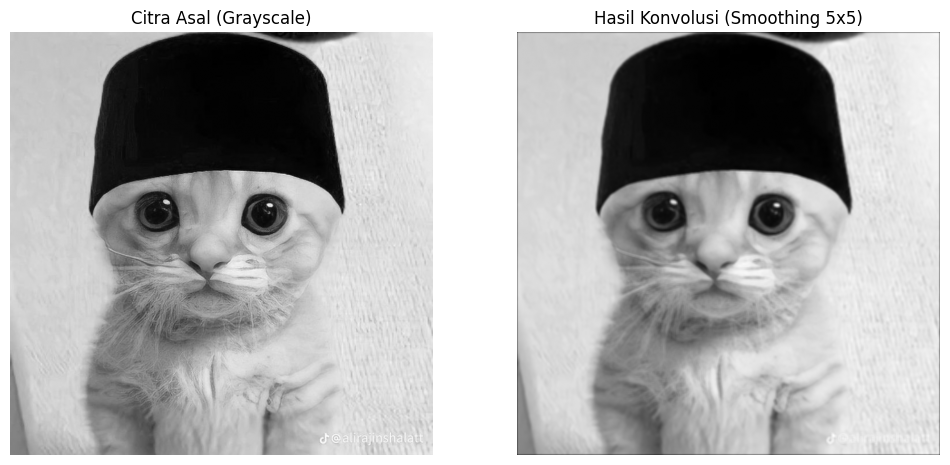

In [ ]:
# Eksekusi fungsi
hasil_konvolusi = konvolusi(img)

# Menampilkan Hasil
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Citra Asal (Grayscale)")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Hasil Konvolusi (Smoothing 5x5)")
plt.imshow(hasil_konvolusi, cmap='gray')
plt.axis('off')

plt.show()